In [1]:
!pip install textblob wordcloud

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
from wordcloud import WordCloud

In [3]:
df = pd.read_csv('/content/tripadvisor_hotel_reviews.csv')

In [4]:
df.head()


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB


In [6]:
df.columns

Index(['Review', 'Rating'], dtype='object')

In [7]:
def get_sentiment(text):

    score = TextBlob(text).sentiment.polarity

    if score > 0:
        return "Positive"

    elif score < 0:
        return "Negative"

    else:
        return "Neutral"

In [8]:
df['Sentiment'] = df['Review'].apply(get_sentiment)

In [9]:
df[['Review','Sentiment']].head()

,Review,Sentiment
0,nice hotel expensive parking got good deal sta...,Positive
1,ok nothing special charge diamond member hilto...,Positive
2,nice rooms not 4* experience hotel monaco seat...,Positive
3,"unique, great stay, wonderful time hotel monac...",Positive
4,"great stay great stay, went seahawk game aweso...",Positive


In [10]:
df['Sentiment'].value_counts()

,count
Sentiment,
Positive,19112
Negative,1356
Neutral,23


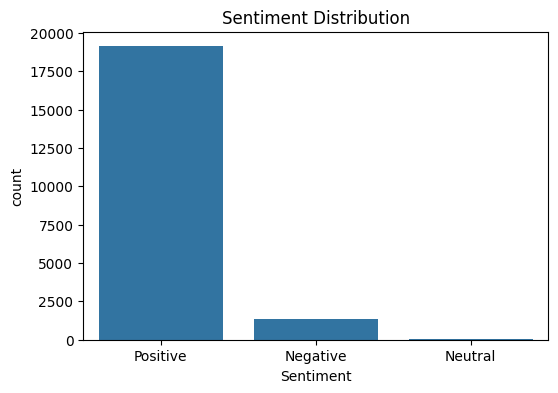

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Sentiment',
    data=df
)

plt.title("Sentiment Distribution")

plt.show()

In [12]:
positive_text = " ".join(
    df[df['Sentiment']=="Positive"]['Review']
)

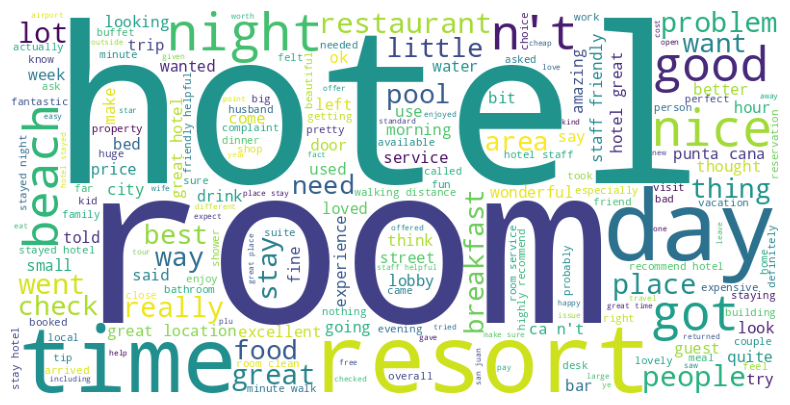

In [13]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [14]:
negative_text = " ".join(
    df[df['Sentiment']=="Negative"]['Review']
)

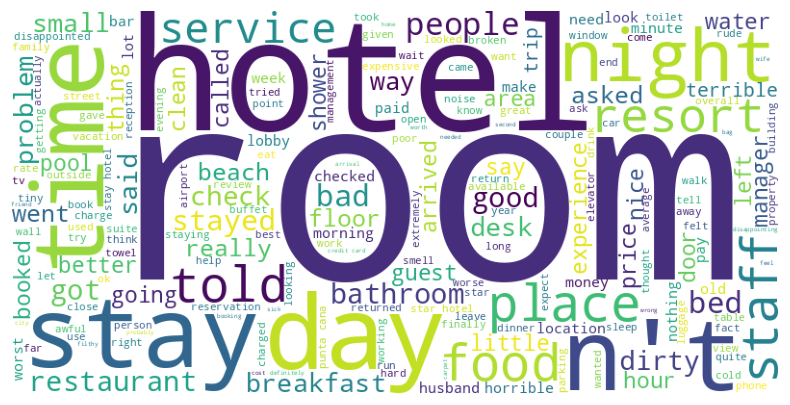

In [15]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [16]:
df.to_csv(
    "sentiment_results.csv",
    index=False
)